In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
from scipy import stats

from src.processing import criando_cenarios_amostragem, amostrar_por_regiao
from src.statistics import comparar_distribuicoes, gerar_amostras_mcmc_por_problema
from src.visualization import plota_comparacao_distribuicoes

# 1. Distribuicoes empiricas de erro

- Sampling para gerar conjunto de validacao do erro empirico (só 3% uniforme mesmo)
- Captura distribuicoes e estatisticas (media e desvpad) de erro
    - Por regiao/problema
- Kolmogorov Smirnoff para comparar com distribuicao do erro usando (100%) da base como validacao vs. 3%
- Super analise com print, resultado/valor do KS, histogramas sobrepostos das 2 distribuicoes, estatisticas do erro na base 3% e na base 100%, WAPE

In [2]:
df_surrogate1 = pd.read_parquet('data/df_surrogate1.parquet')
df_surrogate2 = pd.read_parquet('data/df_surrogate2.parquet')

### I. Amostragem

In [4]:
# define parametros para criacao de cenários de amostragem
taxa_amostragem_global = 0.03 #1/10 do conjunto de treino
n_regioes = 10
proporcionalidade = 15

# definindo cenários de amostragem
df_amostragem1 = criando_cenarios_amostragem(df_surrogate1, 
                                taxa_amostragem_global,
                                n_regioes,
                                proporcionalidade)

df_amostragem2 = criando_cenarios_amostragem(df_surrogate2, 
                                taxa_amostragem_global,
                                n_regioes,
                                proporcionalidade)

# realizando amostragem por cenário
df_validacao1 = amostrar_por_regiao(df_surrogate1, df_amostragem1, 'cenario1')
df_validacao2 = amostrar_por_regiao(df_surrogate2, df_amostragem2, 'cenario1')


# tamanho das amostras
#display(df_validacao1.groupby('regiao').size().reset_index(name='count'))
display(df_validacao2.groupby('regiao').size().reset_index(name='count'))
display(df_surrogate1.groupby('regiao').size().reset_index(name='count'))
#display(df_surrogate2.groupby('regiao').size().reset_index(name='count'))

taxa % amostragem média


cenario1    0.030000
cenario2    0.042517
cenario3    0.043283
dtype: float64

taxa % amostragem média


cenario1    0.030000
cenario2    0.039219
cenario3    0.033997
dtype: float64

,regiao,count
0,0.0,3000
1,10.0,3000
2,2.0,3000
3,4.0,9000
4,6.0,3000
5,8.0,9000


,regiao,count
0,0.0,100000
1,10.0,100000
2,2.0,100000
3,4.0,300000
4,6.0,100000
5,8.0,300000


### II. Kolmogorov-Smirnov

In [5]:
# Problema 1
df_dist1_f1 = comparar_distribuicoes(df_surrogate1, df_validacao1, col='erro1_c1', problema='problema1')
df_dist1_f2 = comparar_distribuicoes(df_surrogate1, df_validacao1, col='erro2_c1', problema='problema1')

# Problema 2
df_dist2_f1 = comparar_distribuicoes(df_surrogate2, df_validacao2, col='erro1_c1', problema='problema2')
df_dist2_f2 = comparar_distribuicoes(df_surrogate2, df_validacao2, col='erro2_c1', problema='problema2')

# Combinar todos os resultados
df_todos_resultados = pd.concat([df_dist1_f1, df_dist1_f2, df_dist2_f1, df_dist2_f2], ignore_index=True)

display(df_todos_resultados.head())

,problema,objetivo,regiao,coluna,ks_statistic,ks_pvalue,distribuicoes_iguais,media_geral,media_validacao,desvpad_geral,desvpad_validacao,size_geral,size_validacao,wape_geral,wape_validacao
0,problema1,fitness1,0.0,erro1_c1,0.012127,0.780212,Sim,0.774974,0.782737,0.539078,0.531071,100000,3000,0.211298,0.210785
1,problema1,fitness1,10.0,erro1_c1,0.018570,0.264312,Sim,1.927524,1.910402,0.853636,0.857304,100000,3000,0.396651,0.392246
2,problema1,fitness1,2.0,erro1_c1,0.015790,0.457316,Sim,-0.954179,-0.958500,0.352920,0.349303,100000,3000,0.452517,0.455399
3,problema1,fitness1,4.0,erro1_c1,0.006156,0.892987,Sim,0.159709,0.152348,0.836057,0.839624,300000,9000,0.245642,0.246593
4,problema1,fitness1,6.0,erro1_c1,0.020667,0.163724,Sim,-0.246402,-0.234176,0.474949,0.472387,100000,3000,0.163548,0.159907


Plotando comparações de distribuições - Problema 1...


/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:1221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.99], pad=0.5)
/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


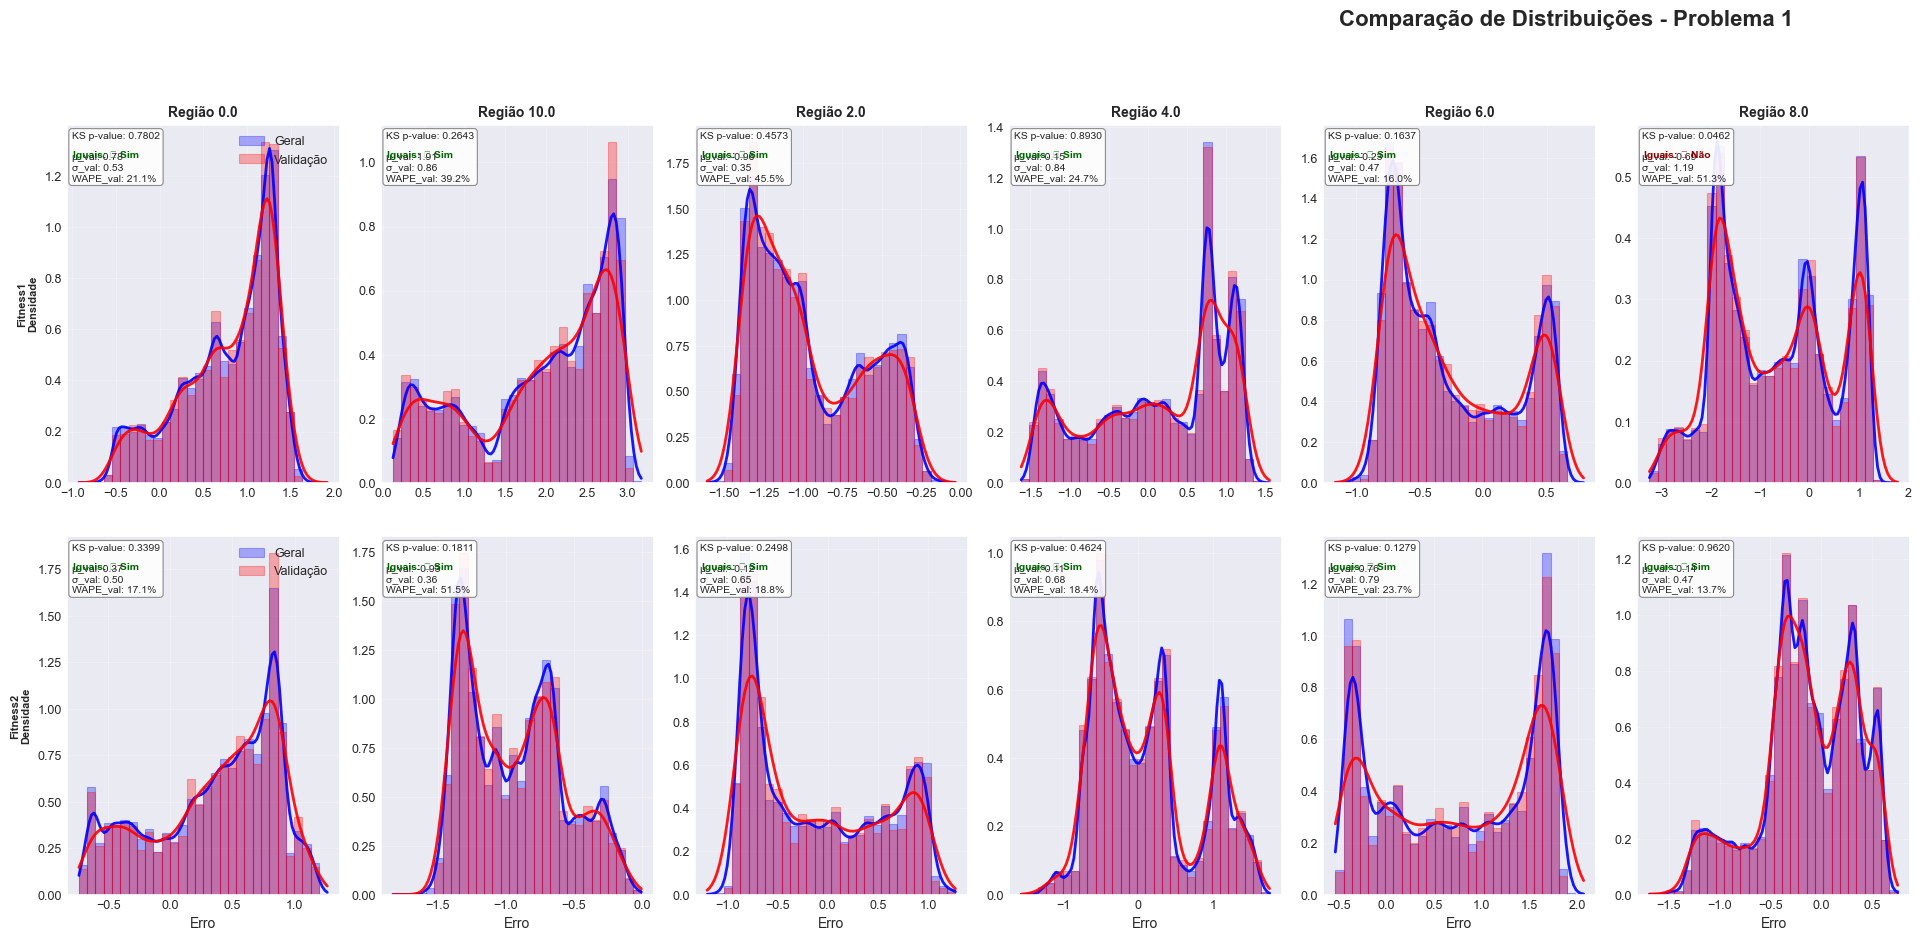

Plotando comparações de distribuições - Problema 2...


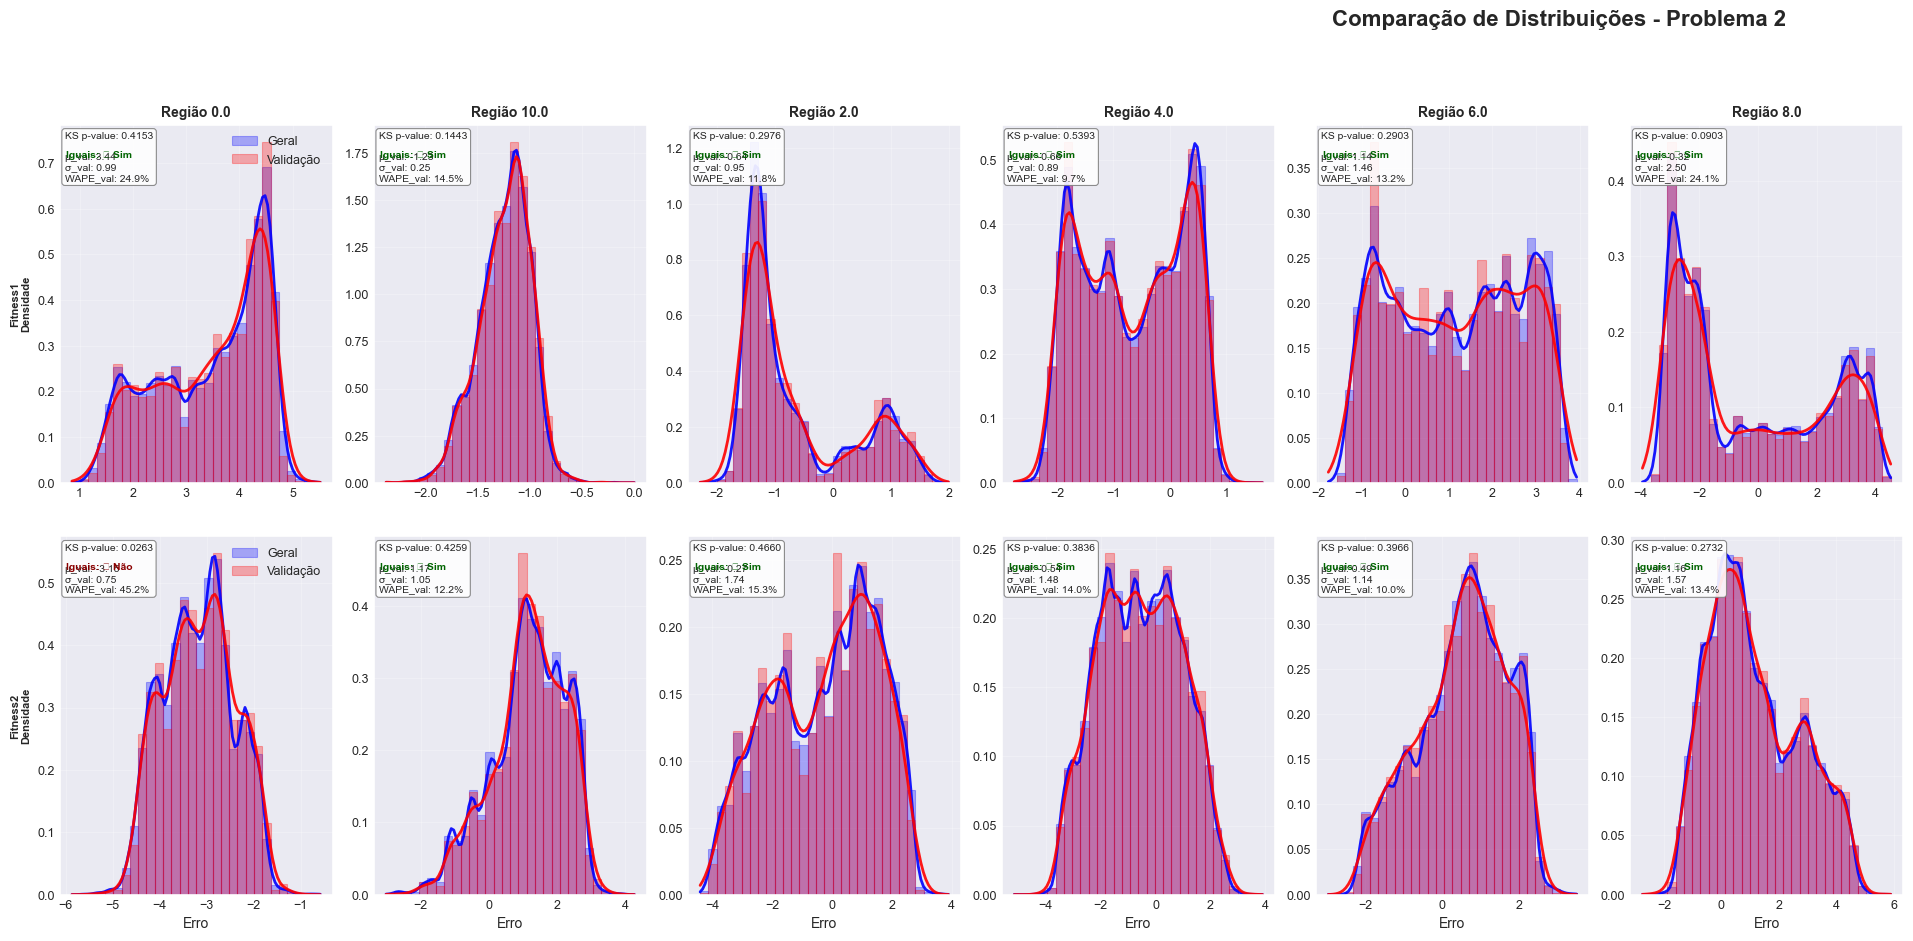

In [6]:
# Visualizar comparações de distribuições - Problema 1
print("Plotando comparações de distribuições - Problema 1...")
plota_comparacao_distribuicoes(df_surrogate1, df_validacao1, df_todos_resultados, problema_num=1)

# Visualizar comparações de distribuições - Problema 2
print("Plotando comparações de distribuições - Problema 2...")
plota_comparacao_distribuicoes(df_surrogate2, df_validacao2, df_todos_resultados, problema_num=2)

# 2. MCMC
**Algoritmo:** Metropolis-Hastings com Kernel Density Estimation (KDE)
- Gera via MCMC amostras das distribuicoes de erros (por problema/regiao)
- Kolmogorov-Smirnov + analise distribuicoes para comparar: amostra gerada mcmc vs. distribuicoes do erro em validacao (3%) e base completa (100%)

In [7]:
df_mcmc1 = gerar_amostras_mcmc_por_problema(
    df_validacao=df_validacao1,
    n_samples=30
)

df_mcmc2 = gerar_amostras_mcmc_por_problema(
    df_validacao=df_validacao2,
    n_samples=30,
)

#df_mcmc1.to_parquet('data/df_mcmc1.parquet')
#df_mcmc2.to_parquet('data/df_mcmc2.parquet')

print(f"  - df_mcmc1 (Problema 1): {len(df_mcmc1)} amostras")
print(f"  - df_mcmc2 (Problema 2): {len(df_mcmc2)} amostras")
display(df_mcmc1.head())
display(df_mcmc2.head())


🔄 GERANDO AMOSTRAS MCMC PARA PROBLEMA
Colunas: erro1_c1 e erro2_c1
Amostras por região: 30

📊 Gerando amostras para erro1_c1...


Gerando amostras MCMC por região para coluna 'erro1_c1'
Modo adaptativo: Ativado
Proposal scale: 0.7

📍 Região 0.0:
MCMC completado:
  - Total de iterações: 1,300
  - Burn-in: 1,000
  - Thinning: 10
  - Amostras geradas: 30
  - Taxa de aceitação: 55.23%
  - Proposal std final: 1.1099
  ✅ Taxa de aceitação adequada (15-70%).
  📊 Comparação de estatísticas:
     Original  - Média:   0.7827, Std:   0.5311
     MCMC      - Média:   0.6914, Std:   0.5771

📍 Região 10.0:
MCMC completado:
  - Total de iterações: 1,300
  - Burn-in: 1,000
  - Thinning: 10
  - Amostras geradas: 30
  - Taxa de aceitação: 52.31%
  - Proposal std final: 1.7916
  ✅ Taxa de aceitação adequada (15-70%).
  📊 Comparação de estatísticas:
     Original  - Média:   1.9104, Std:   0.8573
     MCMC      - Média:   1.4069, Std:   0.8736

📍 Região 2.0:
MCMC completado:
  - Total de iterações: 1,300

,index_linha,regiao,erro1_c1,erro2_c1
0,0,0.0,0.941877,0.665557
1,1,0.0,1.025598,0.743599
2,2,0.0,-0.586987,-0.673639
3,3,0.0,0.208927,0.801200
4,4,0.0,0.551124,-0.426516


,index_linha,regiao,erro1_c1,erro2_c1
0,0,0.0,3.093273,-3.085394
1,1,0.0,4.290626,-1.999468
2,2,0.0,2.472523,-3.648375
3,3,0.0,3.319718,-3.713989
4,4,0.0,1.409960,-4.487806


#### 2. Problema 2

Plotando comparações de distribuições - Problema 1...


/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:1221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.99], pad=0.5)
/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


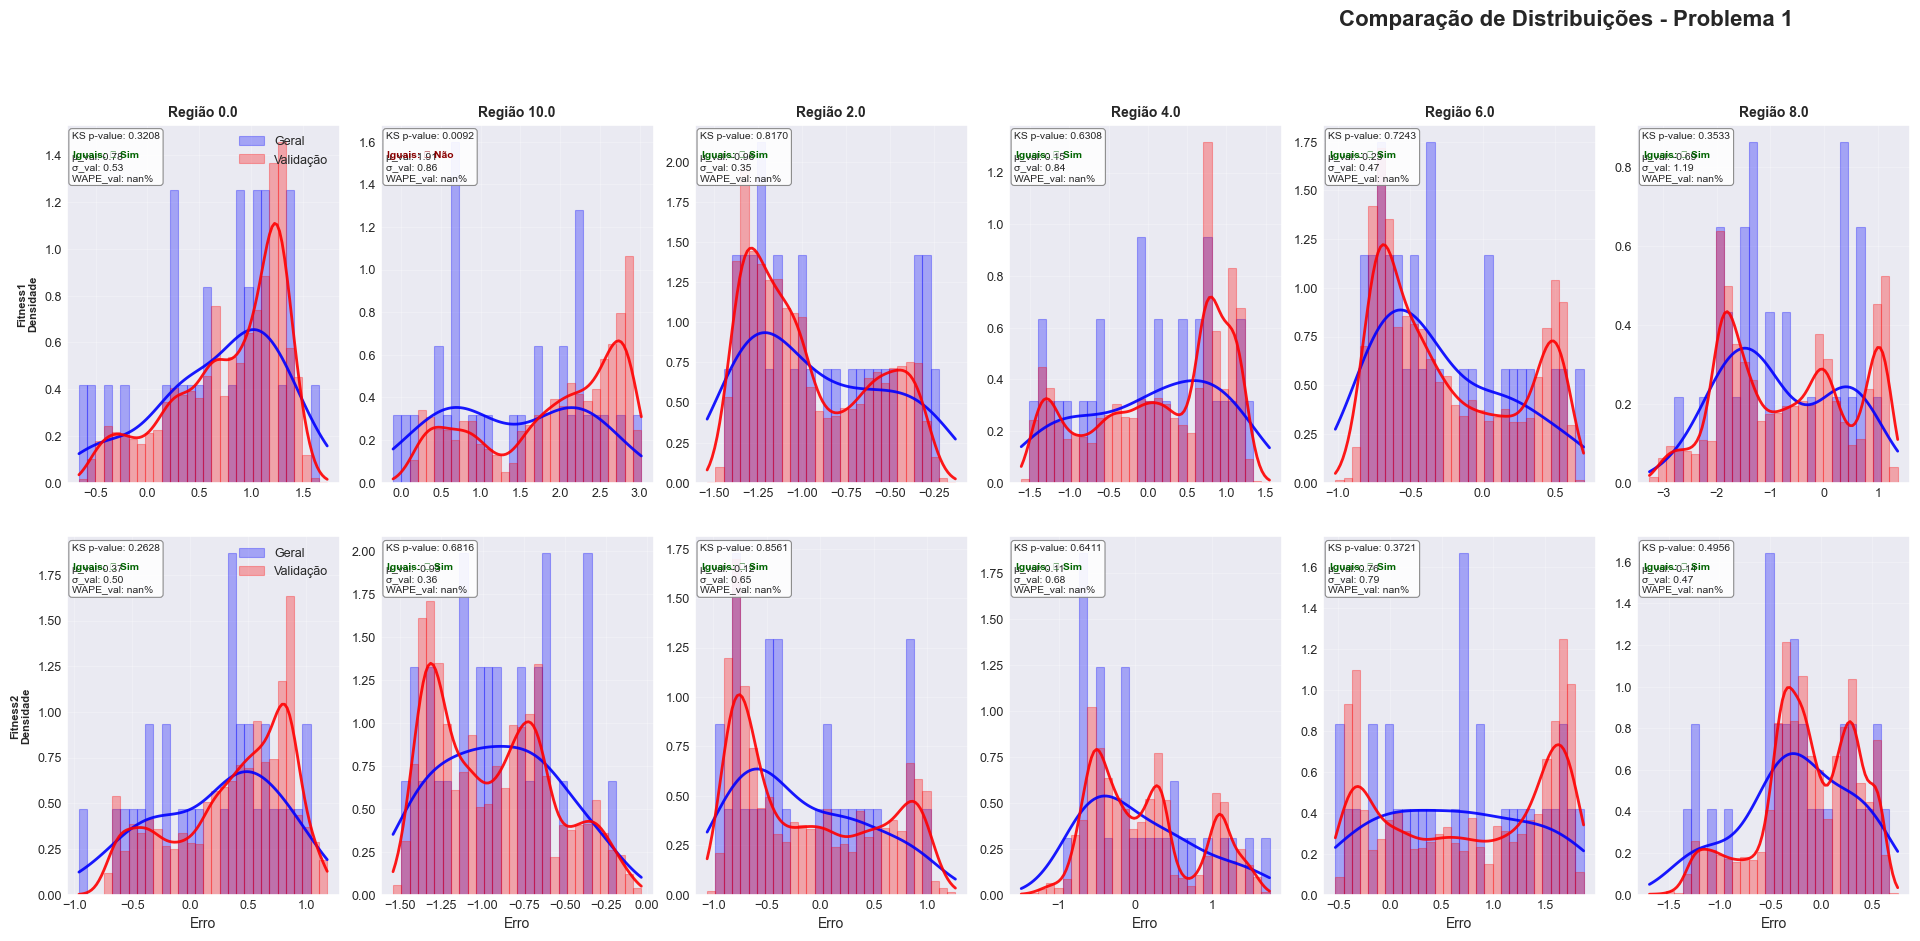

Plotando comparações de distribuições - Problema 2...


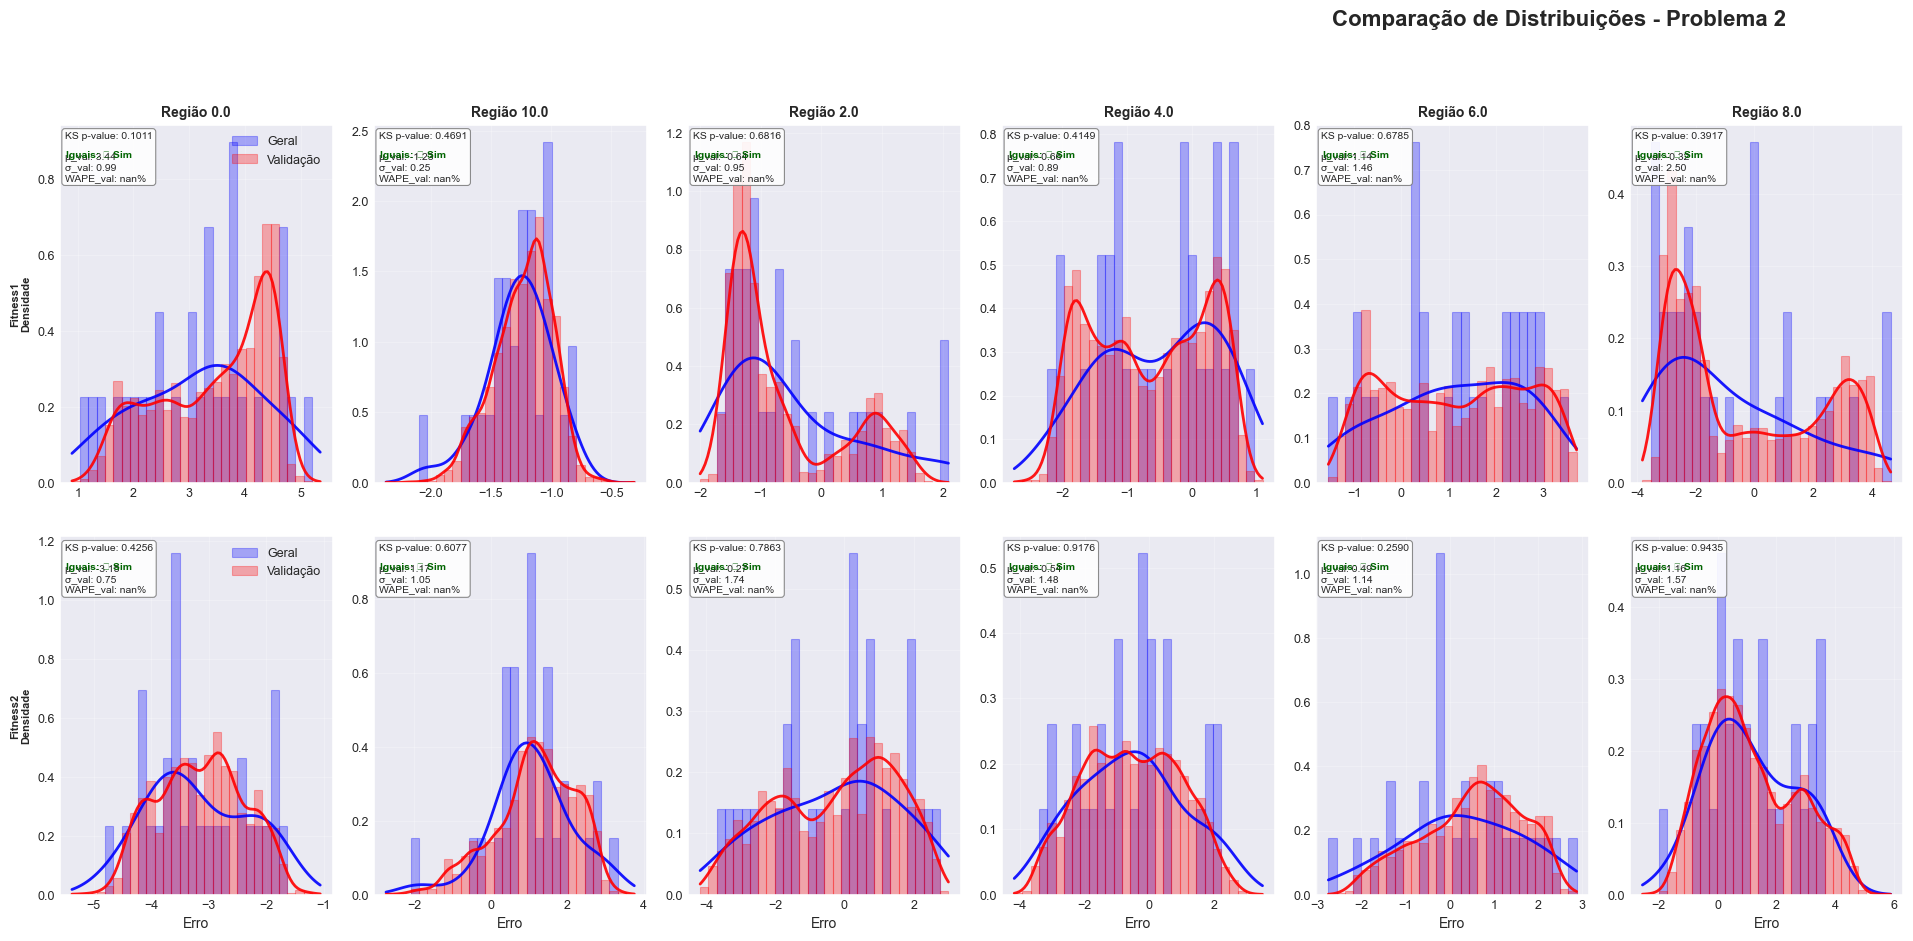

In [8]:
# Problema 1
df_dist1_f1 = comparar_distribuicoes(df_mcmc1, df_validacao1, col='erro1_c1', problema='problema1', calcula_wape=False)
df_dist1_f2 = comparar_distribuicoes(df_mcmc1, df_validacao1, col='erro2_c1', problema='problema1', calcula_wape=False)

# Problema 2
df_dist2_f1 = comparar_distribuicoes(df_mcmc2, df_validacao2, col='erro1_c1', problema='problema2', calcula_wape=False)
df_dist2_f2 = comparar_distribuicoes(df_mcmc2, df_validacao2, col='erro2_c1', problema='problema2', calcula_wape=False)

# Combinar todos os resultados
df_todos_resultados = pd.concat([df_dist1_f1, df_dist1_f2, df_dist2_f1, df_dist2_f2], ignore_index=True)

# Visualizar comparações de distribuições - Problema 1
print("Plotando comparações de distribuições - Problema 1...")
plota_comparacao_distribuicoes(df_mcmc1, df_validacao1, df_todos_resultados, problema_num=1)

# Visualizar comparações de distribuições - Problema 2
print("Plotando comparações de distribuições - Problema 2...")
plota_comparacao_distribuicoes(df_mcmc2, df_validacao2, df_todos_resultados, problema_num=2)

Plotando comparações de distribuições - Problema 1...


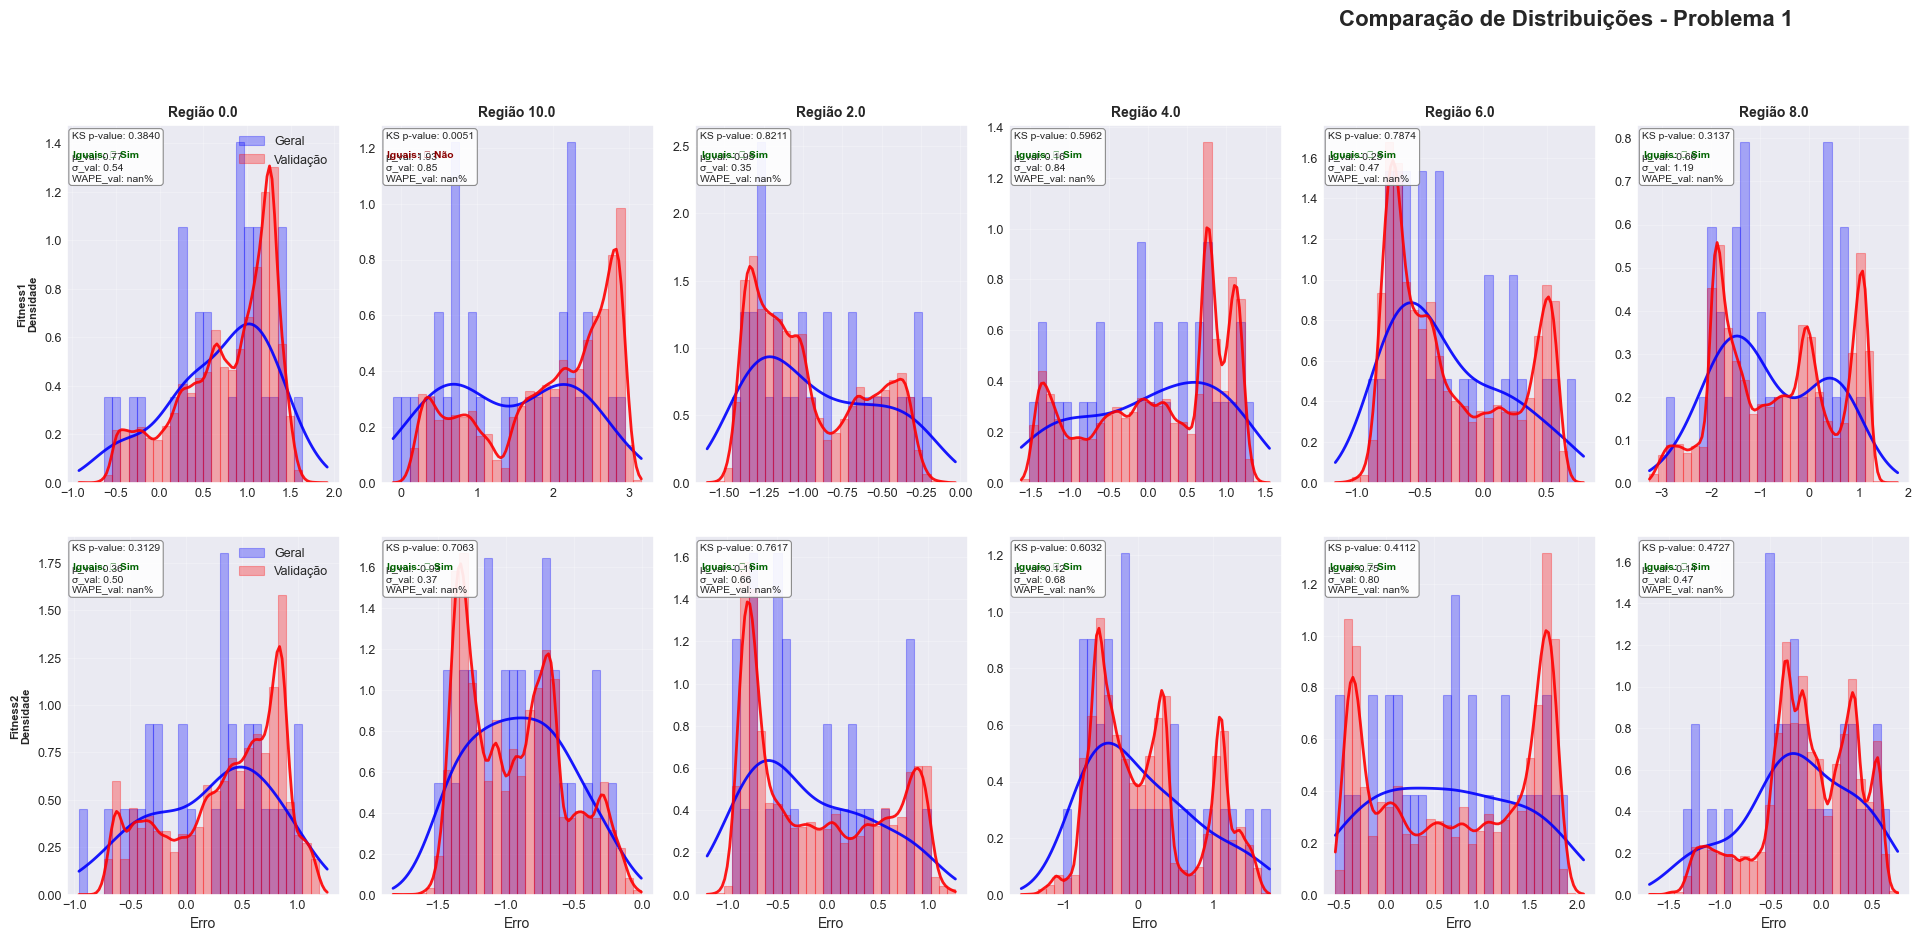

Plotando comparações de distribuições - Problema 2...


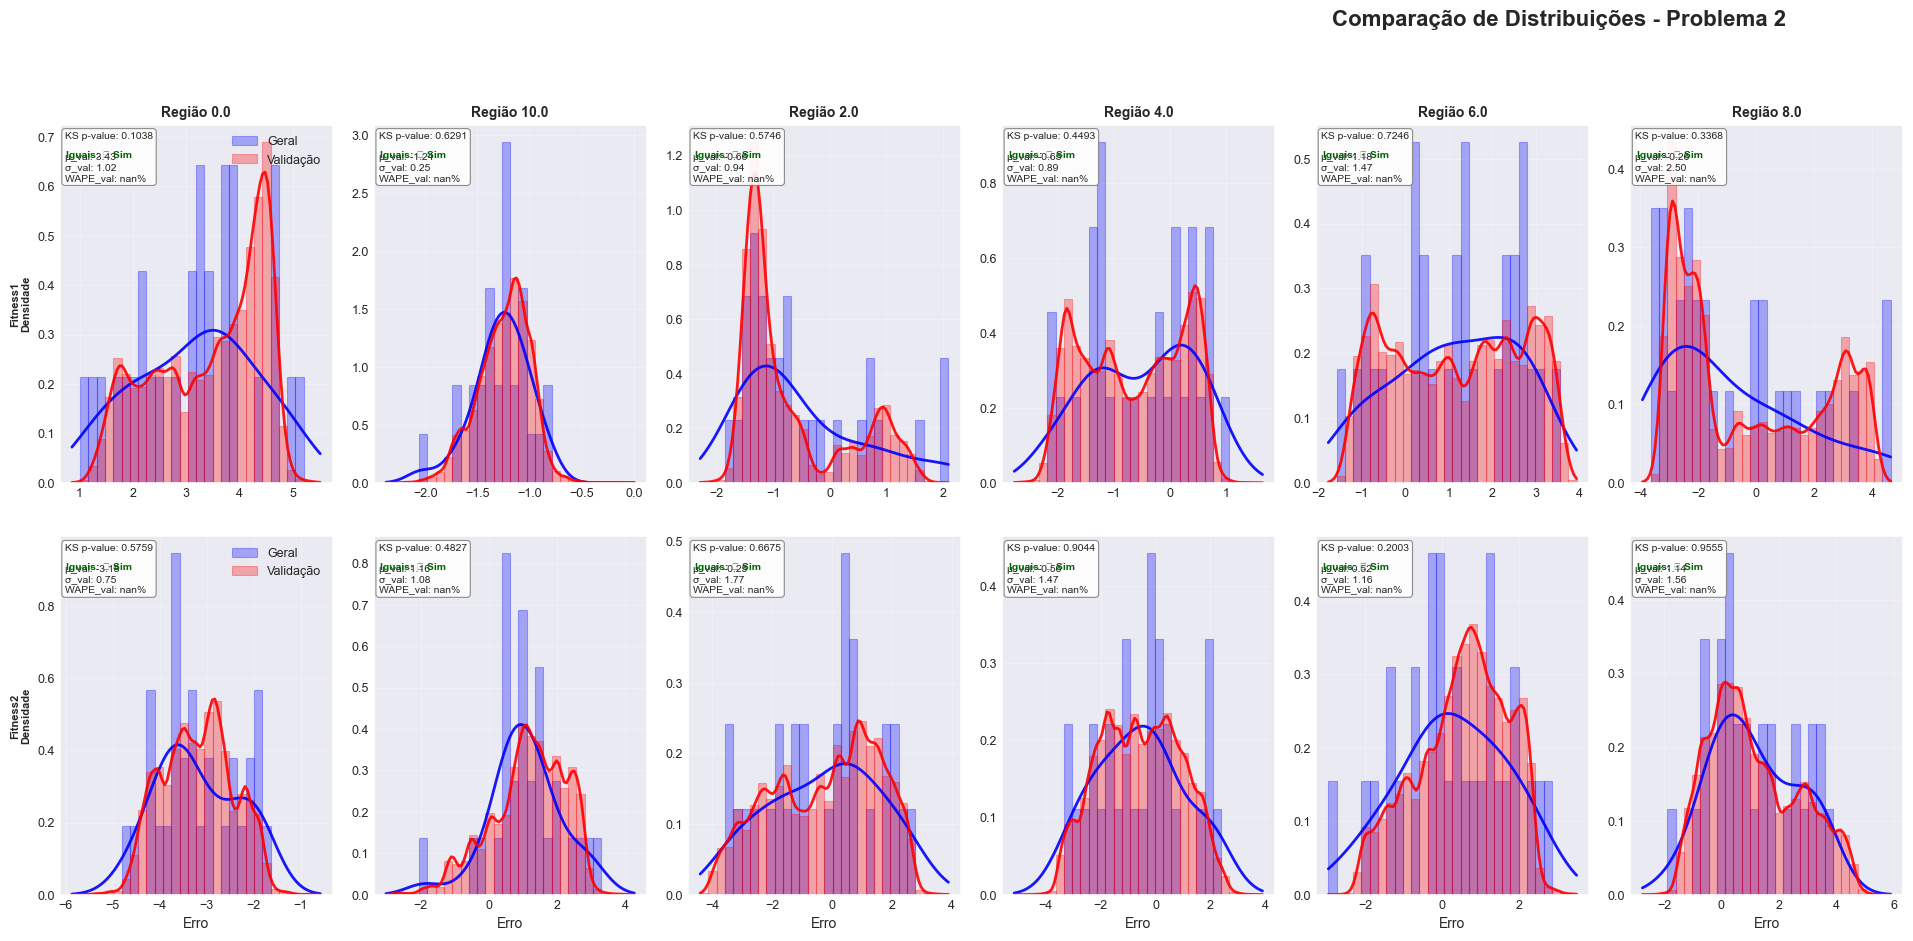

In [9]:
# Problema 1
df_dist1_f1 = comparar_distribuicoes(df_mcmc1, df_surrogate1, col='erro1_c1', problema='problema1', calcula_wape=False)
df_dist1_f2 = comparar_distribuicoes(df_mcmc1, df_surrogate1, col='erro2_c1', problema='problema1', calcula_wape=False)

# Problema 2
df_dist2_f1 = comparar_distribuicoes(df_mcmc2, df_surrogate2, col='erro1_c1', problema='problema2', calcula_wape=False)
df_dist2_f2 = comparar_distribuicoes(df_mcmc2, df_surrogate2, col='erro2_c1', problema='problema2', calcula_wape=False)

# Combinar todos os resultados
df_todos_resultados = pd.concat([df_dist1_f1, df_dist1_f2, df_dist2_f1, df_dist2_f2], ignore_index=True)

# Visualizar comparações de distribuições - Problema 1
print("Plotando comparações de distribuições - Problema 1...")
plota_comparacao_distribuicoes(df_mcmc1, df_surrogate1, df_todos_resultados, problema_num=1)

# Visualizar comparações de distribuições - Problema 2
print("Plotando comparações de distribuições - Problema 2...")
plota_comparacao_distribuicoes(df_mcmc2, df_surrogate2, df_todos_resultados, problema_num=2)